In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/Video_Games_Sales_as_at_22_Dec_2016.csv')

## UNDERSTAND THE RAW DATA!

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(16719, 16)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16448 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16448 non-null  object 
 1   Platform         16448 non-null  object 
 2   Year_of_Release  16448 non-null  int64  
 3   Genre            16448 non-null  object 
 4   Publisher        16448 non-null  object 
 5   NA_Sales         16448 non-null  float64
 6   EU_Sales         16448 non-null  float64
 7   JP_Sales         16448 non-null  float64
 8   Other_Sales      16448 non-null  float64
 9   Global_Sales     16448 non-null  float64
 10  Critic_Score     7983 non-null   float64
 11  Critic_Count     7983 non-null   float64
 12  User_Score       9840 non-null   object 
 13  User_Count       7463 non-null   float64
 14  Developer        9907 non-null   object 
 15  Rating           9769 non-null   object 
dtypes: float64(8), int64(1), object(7)
memory usage: 2.1+ MB


In [15]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16448.000000,16448.000000,16448.000000,16448.000000,16448.000000,16448.00000,7983.000000,7983.000000,7463.000000
mean,2006.488996,0.263965,0.145895,0.078472,0.047583,0.53617,68.994363,26.441313,163.015141
std,5.877470,0.818286,0.506660,0.311064,0.187984,1.55846,13.920060,19.008136,563.863327
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.01000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.06000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.17000,71.000000,22.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.47000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.53000,98.000000,113.000000,10665.000000


In [13]:
df.nunique()

Name               11429
Platform              31
Year_of_Release       39
Genre                 12
Publisher            579
NA_Sales             401
EU_Sales             307
JP_Sales             244
Other_Sales          155
Global_Sales         628
Critic_Score          81
Critic_Count         106
User_Score            96
User_Count           883
Developer           1680
Rating                 8
dtype: int64

In [6]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

## Data Cleaning

In [7]:
df = df.dropna(axis=0, subset=['Name','Year_of_Release'])

In [8]:
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [9]:
years = df['Year_of_Release'].unique()
years.sort()
years

array([1980., 1981., 1982., 1983., 1984., 1985., 1986., 1987., 1988.,
       1989., 1990., 1991., 1992., 1993., 1994., 1995., 1996., 1997.,
       1998., 1999., 2000., 2001., 2002., 2003., 2004., 2005., 2006.,
       2007., 2008., 2009., 2010., 2011., 2012., 2013., 2014., 2015.,
       2016., 2017., 2020.])

In [10]:
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

In [11]:
display(df.head())
display(df.isnull().sum())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8465
Critic_Count       8465
User_Score         6608
User_Count         8985
Developer          6541
Rating             6679
dtype: int64

## Univariate EDA

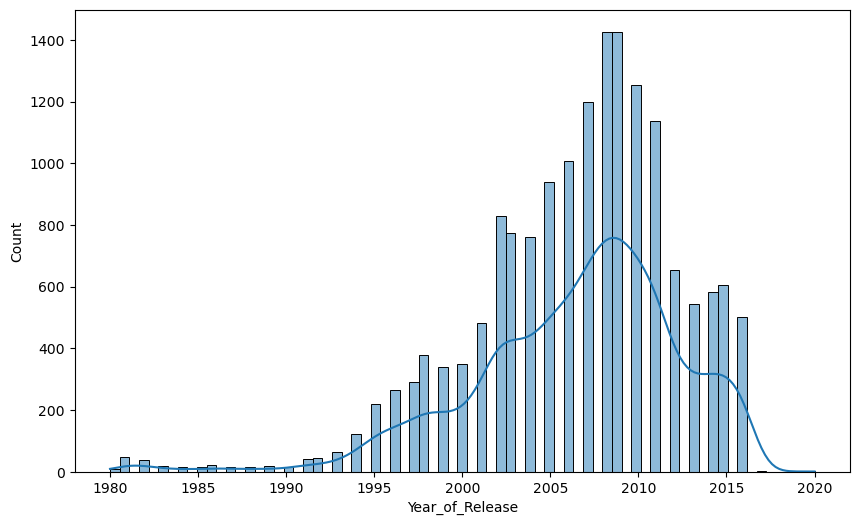

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=df,x='Year_of_Release', kde=True)
plt.show()

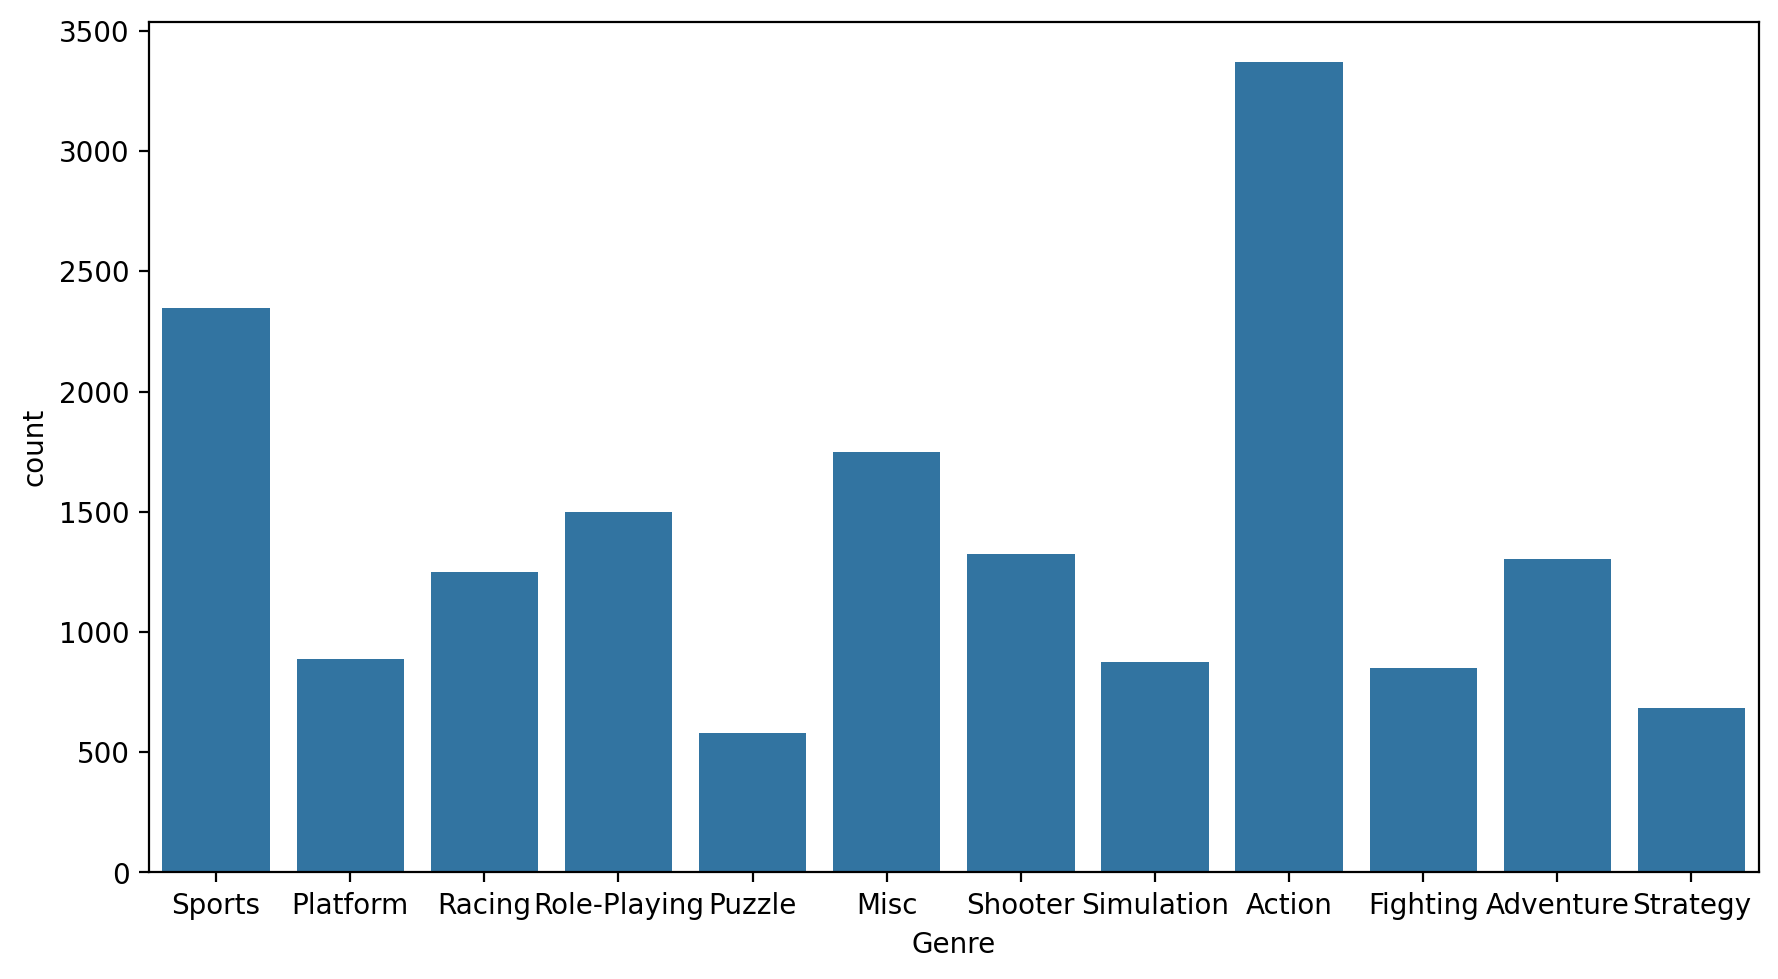

In [34]:
fix, ax = plt.subplots(figsize=(9,5), dpi=200)
sns.countplot(data=df, x='Genre')
plt.tight_layout()
plt.show()

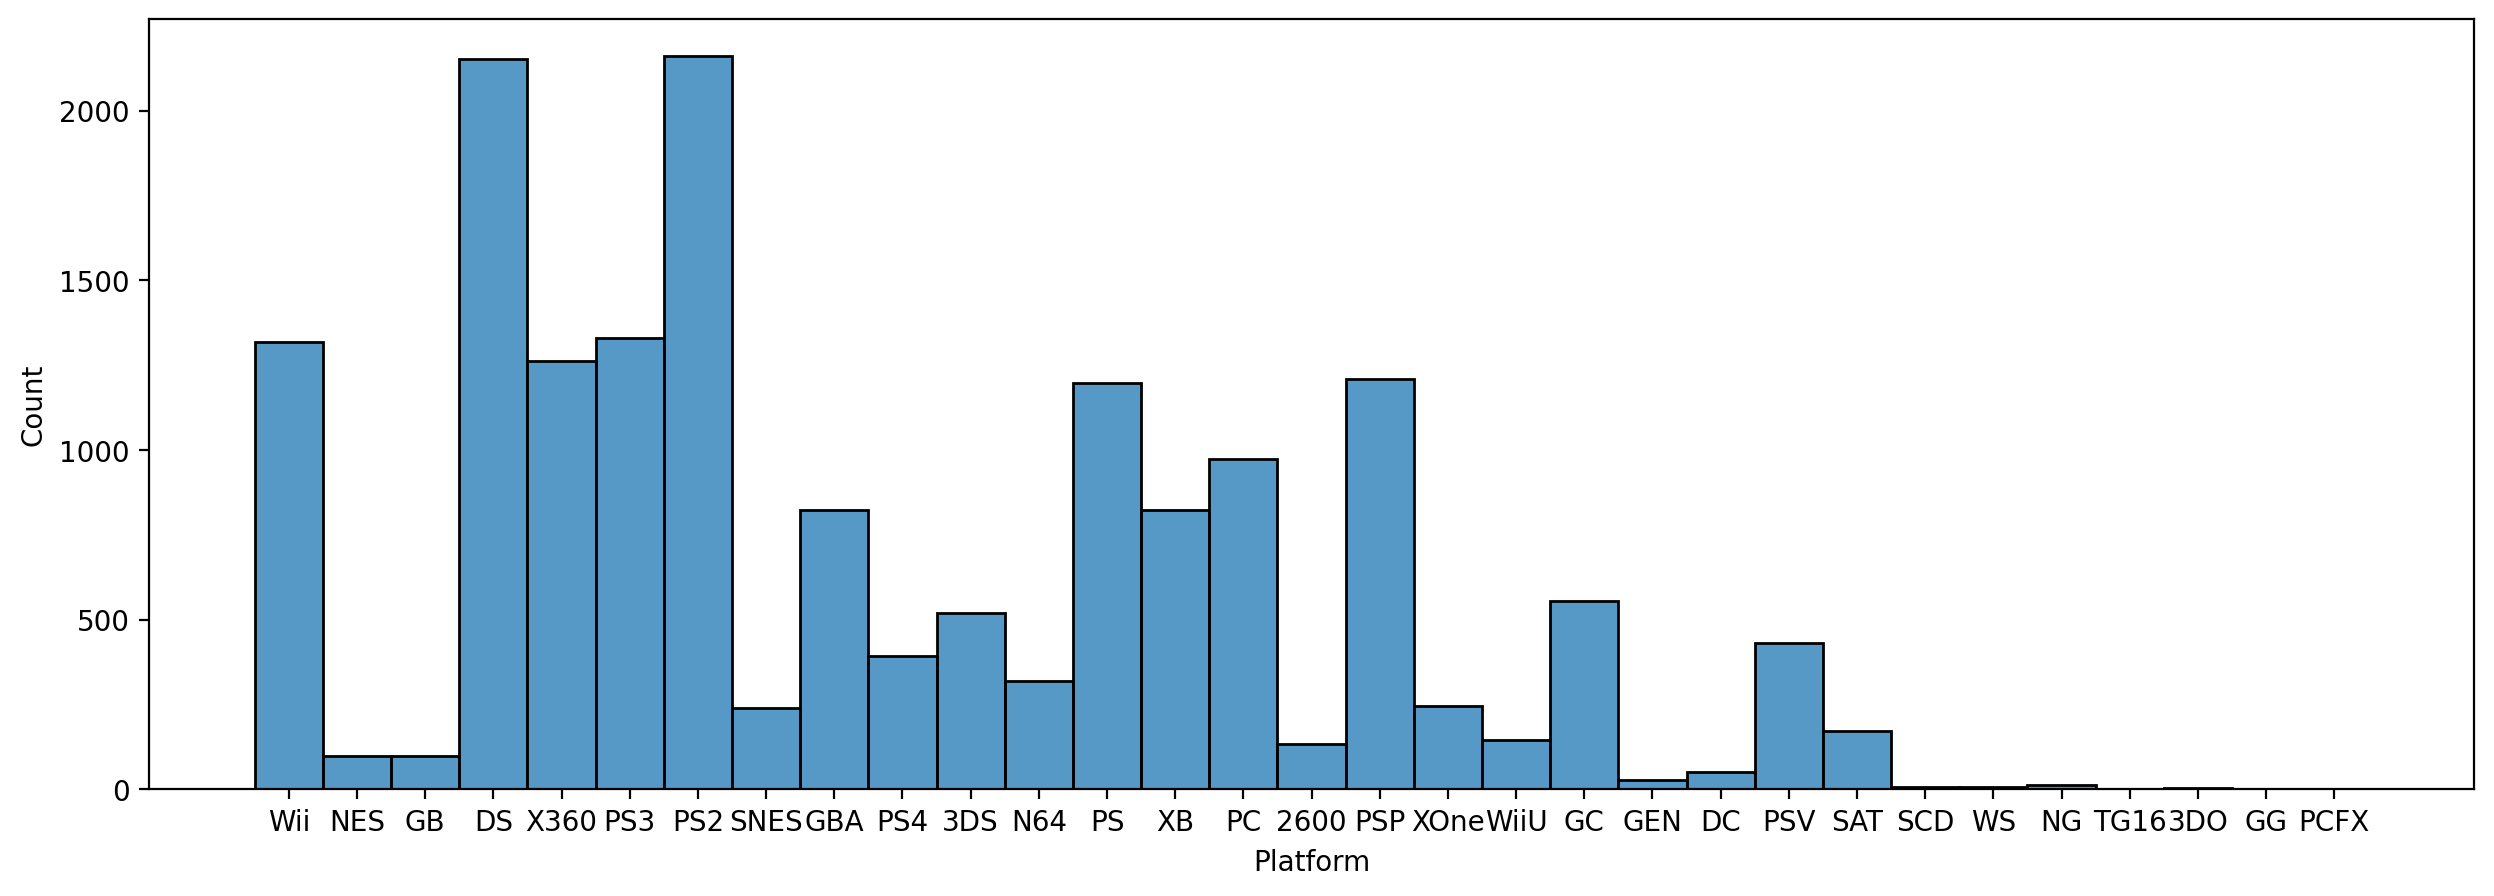

In [43]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Platform')
plt.show()

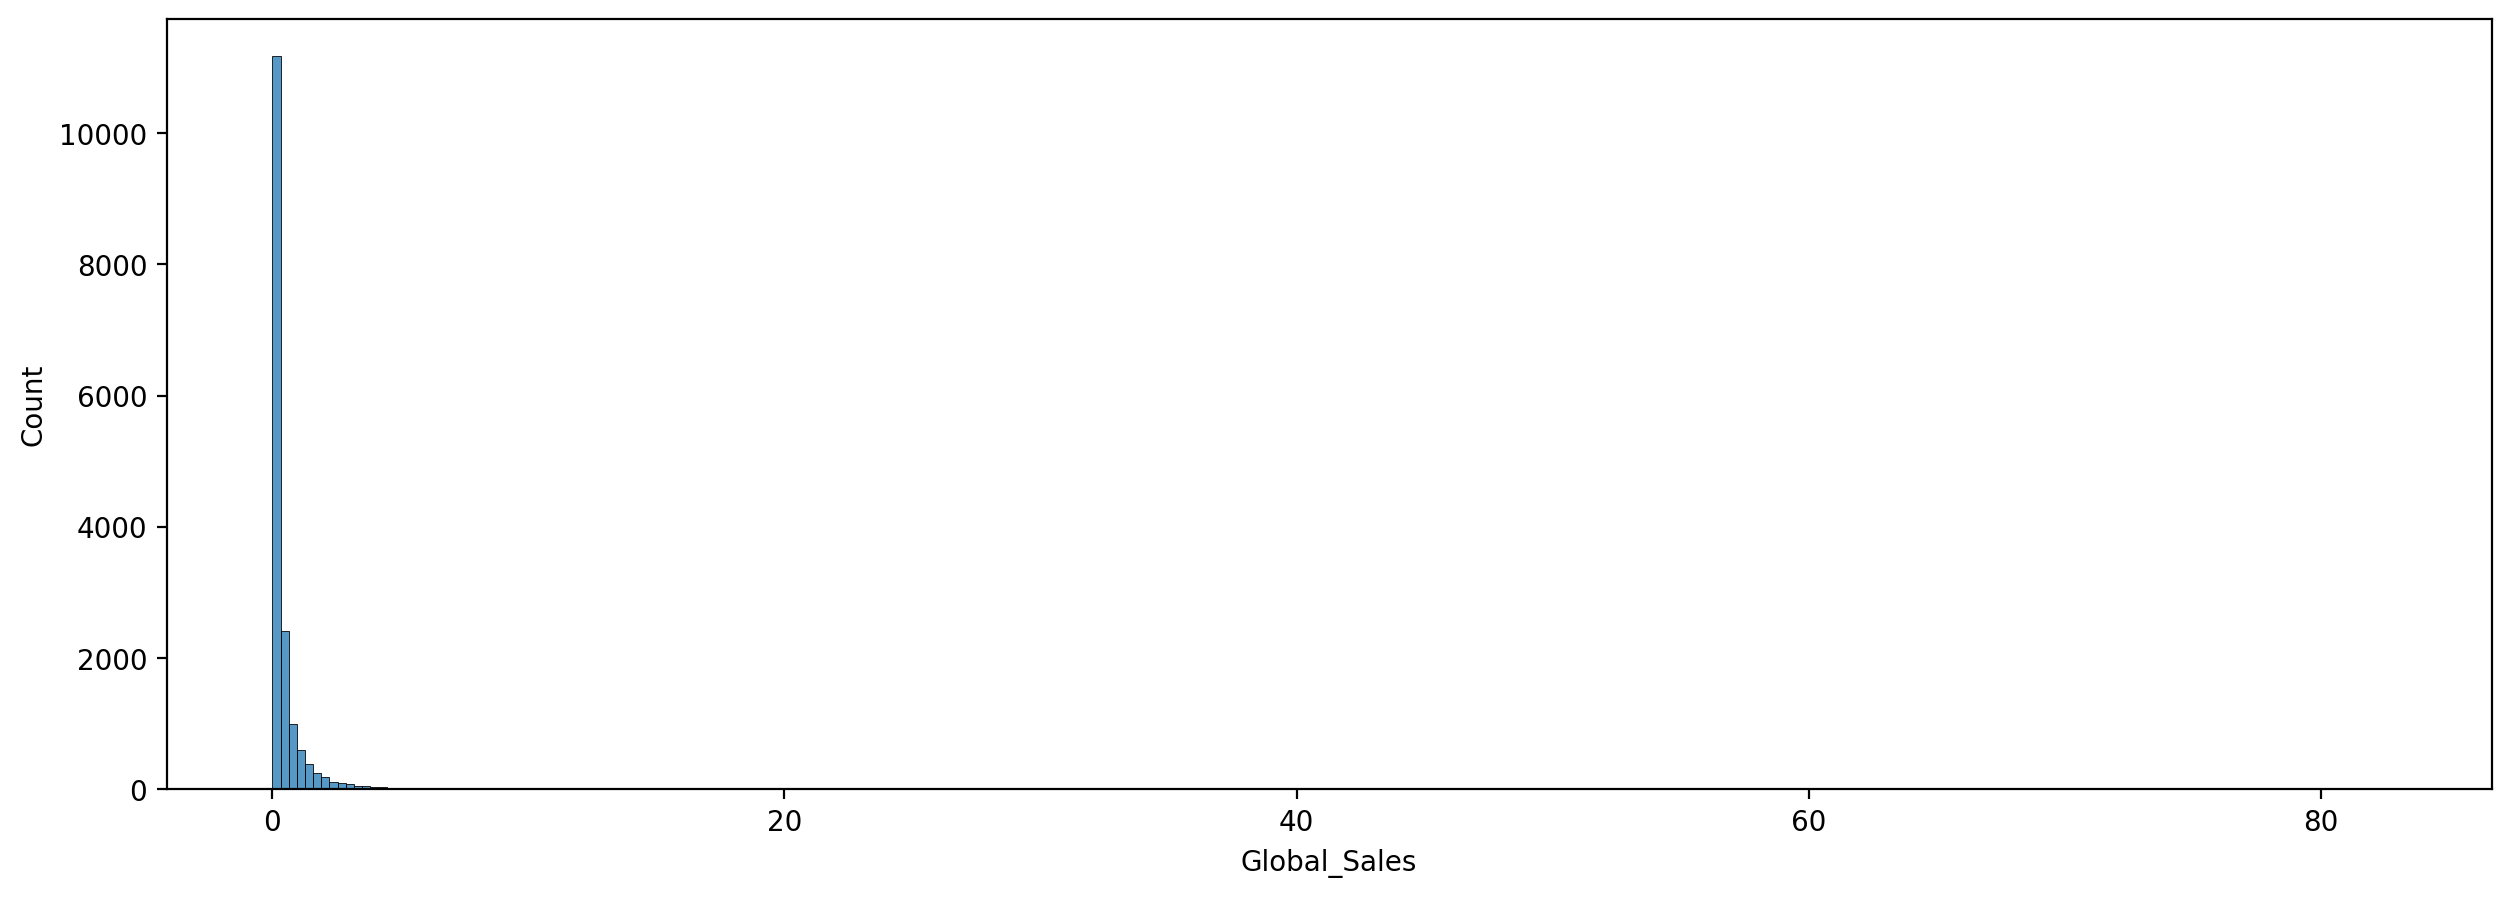

np.float64(87.58298941324242)

In [47]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Global_Sales')
plt.show()
(df['Global_Sales'] < 1).sum() / len(df) * 100

This plot being skewed shows us that if we pick any game on random, there's a high probablity that it either under performed based on sales (had very low sales) while only a handful of games performed so exceptioanlly well that they can be seen as outliers in the given plot. At the end we even calculate the percentage of all games that sold less than a million in our whole dataset and they turned out to be 87.58% of our dataset.

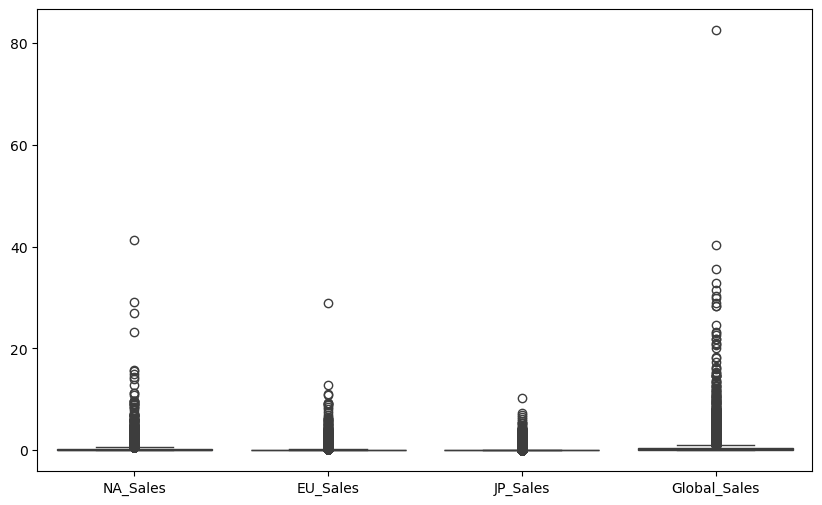

In [49]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']])
plt.show()

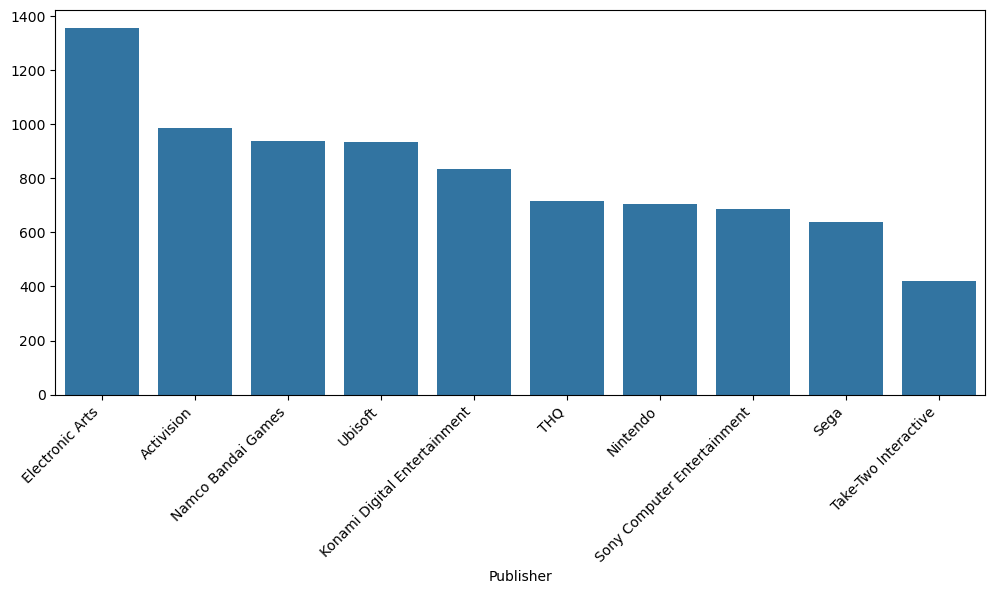

In [81]:
top10_publishers = df['Publisher'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x=top10_publishers.index, y=top10_publishers.values)
plt.xticks(rotation=45, ha='right')
plt.show()

## Bivariate sales focused

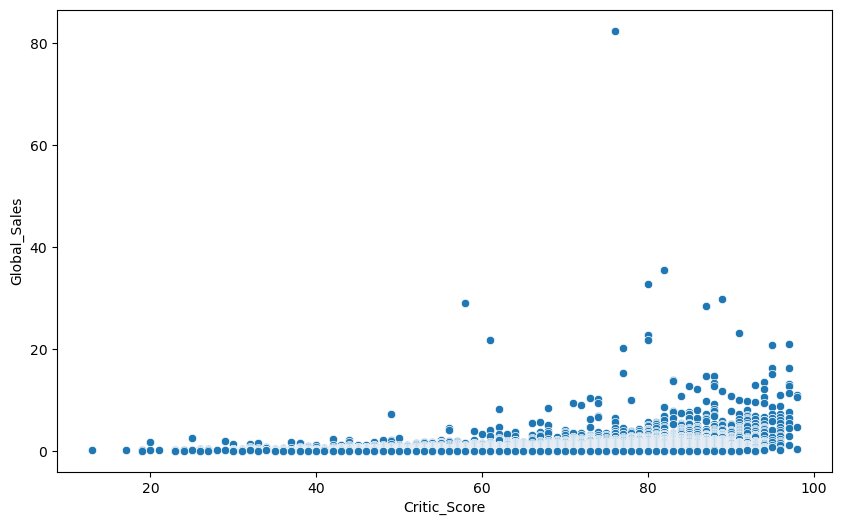

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df,x='Critic_Score', y='Global_Sales')
plt.show()
df.nlargest(5, 'Global_Sales')

<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

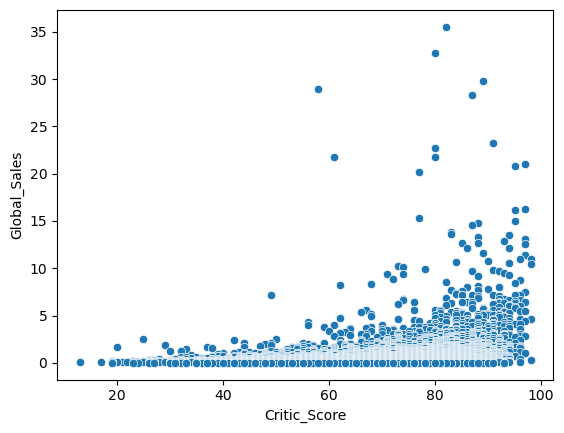

In [82]:
df_no_outlier = df[df['Name'] != 'Wii Sports']
sns.scatterplot(data=df_no_outlier, x='Critic_Score', y='Global_Sales')